# HD Covariance Matrix Sanity Check

This notebook checks the Hellings–Downs (HD) covariance matrix produced by
`hd_full_matrix_snr.py` against the geometric quantities it's built from
(star positions, pairwise separations, and $\gamma_{ab}$ values), and
against the full $C_{ab,cd}$ derivation for all three structural cases:
no shared star, one shared star, and the diagonal (same pair).

**Status as of this version:** `build_HD_matrices` (and the matching
matrix-free `make_hd_matvec`) in `hd_full_matrix_snr.py` has **already
been corrected** to use the full noise convention $P_a = P_{na} + P_{gw}$
for every star, rather than the leading-order $P_a \approx P_{na}$
approximation it used previously. Every numeric result below reflects
that corrected code.

To make the fix visible, this notebook *also* defines a separate,
clearly-named `build_HD_matrices_leading_order` function purely for
side-by-side comparison — it reproduces what the code used to compute,
**before** the fix. Anywhere you see "leading order" vs. "full" /
"corrected" side by side, that's this comparison; everywhere else
("the matrix", "the code"), it means the current, corrected
`build_HD_matrices` actually imported from the file.

Two star-field sizes are used for the geometry/plotting walkthrough
(**N = 3** and **N = 10**), plus a couple of slightly larger fields
(**N = 4** and **N = 6**) used specifically to exercise Case 1 and Case 2
entries, which need at least 4 stars to exist at all.


In [1]:
import numpy as np

# Functions/constants from your existing scripts
from main import (
    build_star_positions,
    pairwise_theta,
    compute_ell_limits,
    gamma_parallel,
    STAR_COORDS_DEG,
    FIELD_SIZE_DEG,
    RANDOM_SEED,
    sigma_bar_sq,
)
# build_HD_matrices here is the CURRENT (corrected) version from the file.
from hd_full_matrix_snr import build_HD_matrices, F_PHYS

# main.py calls matplotlib.use('Agg') on import (needed for headless Slurm
# jobs), which would otherwise stop figures from showing up inline here.
# Re-import after the above and force the inline backend for this notebook.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
%matplotlib inline

print(f"F_PHYS = 192*pi^3 = {F_PHYS:.6f}")
print(f"FIELD_SIZE_DEG (default from main.py) = {FIELD_SIZE_DEG}")
print(f"sigma_bar_sq (= P_n, noise floor) = {sigma_bar_sq:.6e}")


F_PHYS = 192*pi^3 = 5953.205123
FIELD_SIZE_DEG (default from main.py) = 10
sigma_bar_sq (= P_n, noise floor) = 8.461595e-14


## 1. Generate 3 stars and plot their positions

Using `build_star_positions` from `main.py`. We pass `n_stars=3` explicitly
(overriding the default `N_STARS=100` from `main.py`) and reuse the same
`FIELD_SIZE_DEG` and `RANDOM_SEED` so the geometry is reproducible.


Star positions (degrees):
[[ 4.76699767 -1.19804265]
 [ 4.23246234 -2.38307576]
 [-1.80902942 -3.81908767]]


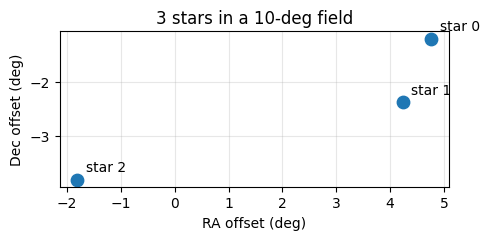

In [2]:
N_STARS_3 = 3

stars_3 = build_star_positions(
    STAR_COORDS_DEG,
    n_stars=N_STARS_3,
    field_size_deg=FIELD_SIZE_DEG,
    seed=RANDOM_SEED,
)

print("Star positions (degrees):")
print(stars_3)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(stars_3[:, 0], stars_3[:, 1], s=80, color="C0")
for i, (x, y) in enumerate(stars_3):
    ax.annotate(f"star {i}", (x, y), textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("RA offset (deg)")
ax.set_ylabel("Dec offset (deg)")
ax.set_title(f"{N_STARS_3} stars in a {FIELD_SIZE_DEG}-deg field")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Histogram of pairwise separations

`pairwise_theta` returns the full N×N separation matrix (radians, NaN on the
diagonal). We pull out the unique upper-triangle pairs and look at their
distribution. With only 3 stars there are just 3 pairs, so this is mostly a
sanity check that the values are non-negative, finite, and reasonable for a
field of this size.

**Note:** because each pair of stars sits at a different angular
separation, each pair will have a different $\theta_{ab}$ -- and
therefore a different $\gamma_{ab}$ below, and a different diagonal
covariance entry later on. The three diagonal entries of the covariance
matrix are *not* expected to be equal to each other; each one belongs to
a geometrically distinct pair.


Pairwise separation matrix (radians):
[[       nan 0.02268949 0.12355404]
 [0.02268949        nan 0.10838165]
 [0.12355404 0.10838165        nan]]

Pairwise separations (degrees): [1.30001211 7.07912489 6.20981101]


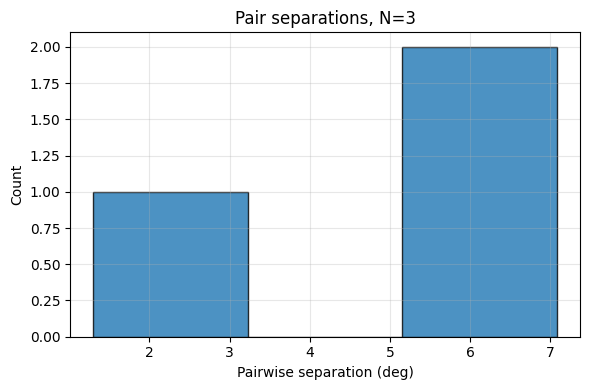

In [3]:
theta_3 = pairwise_theta(stars_3)
print("Pairwise separation matrix (radians):")
print(theta_3)

# Upper-triangle pairs only (avoid double counting / NaN diagonal)
rows3, cols3 = np.triu_indices(N_STARS_3, k=1)
theta_pairs_3 = theta_3[rows3, cols3]
theta_pairs_3_deg = np.degrees(theta_pairs_3)

print("\nPairwise separations (degrees):", theta_pairs_3_deg)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(theta_pairs_3_deg, bins=min(10, len(theta_pairs_3_deg)), color="C0", edgecolor="k", alpha=0.8)
ax.set_xlabel("Pairwise separation (deg)")
ax.set_ylabel("Count")
ax.set_title(f"Pair separations, N={N_STARS_3}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. ell_min / ell_max and histogram of gamma values

`compute_ell_limits` sets `ell_min = 2` and `ell_max` from the minimum
pairwise separation (`2*pi / theta_min`). We then evaluate
`gamma_parallel` on the same separations to get the overlap-function
values for each pair.


ell_min = 2, ell_max = 276

Full gamma matrix (NaN on diagonal):
[[       nan 0.00662549 0.00645776]
 [0.00662549        nan 0.00649727]
 [0.00645776 0.00649727        nan]]

gamma values for each pair: [0.00662549 0.00645776 0.00649727]
(Three different separations -> three different gamma_ab values --
 this is why the covariance matrix's diagonal entries differ from
 each other below; that is expected, not a bug.)


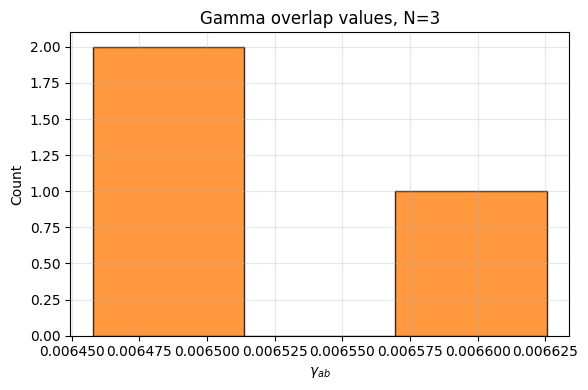

In [4]:
ell_min_3, ell_max_3 = compute_ell_limits(theta_3, FIELD_SIZE_DEG)
print(f"ell_min = {ell_min_3}, ell_max = {ell_max_3}")

gamma_3 = gamma_parallel(theta_3, ell_min_3, ell_max_3)
print("\nFull gamma matrix (NaN on diagonal):")
print(gamma_3)

gamma_pairs_3 = gamma_3[rows3, cols3]
print("\ngamma values for each pair:", gamma_pairs_3)
print("(Three different separations -> three different gamma_ab values --")
print(" this is why the covariance matrix's diagonal entries differ from")
print(" each other below; that is expected, not a bug.)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gamma_pairs_3, bins=min(10, len(gamma_pairs_3)), color="C1", edgecolor="k", alpha=0.8)
ax.set_xlabel(r"$\gamma_{ab}$")
ax.set_ylabel("Count")
ax.set_title(f"Gamma overlap values, N={N_STARS_3}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Build the HD covariance matrix (current, corrected code)

`build_HD_matrices` (imported from `hd_full_matrix_snr.py`, **already
fixed** to use the full $P_a=P_{na}+P_{gw}$ convention) returns the pair
index list and the three pieces `A`, `B`, `D` such that the full
covariance operator is

$$M(r) = A + \frac{B}{r} + \frac{D}{r^2}$$

where $r = P_{gw}/P_n$ is the GW-to-noise power ratio (the x-axis variable
in the SNR curves). We pick one value of `r` to make the matrix concrete.

**Reading the printed matrix:** the three diagonal entries correspond to
the three *different* star pairs $(0,1)$, $(0,2)$, $(1,2)$ -- they are
expected to differ from each other (see note in Section 2/3). The actual
check -- whether each diagonal entry matches *its own* independently
calculated value -- comes in Section 6.


In [5]:
pairs_3, A_3, B_3, D_3 = build_HD_matrices(gamma_3)
print("Pair list (star index a, star index b):")
print(pairs_3)

r_test = 1e-3   # arbitrary but representative GW-to-noise ratio for this check
M_3 = A_3 + B_3 / r_test + D_3 / r_test**2

print(f"\nM(r={r_test:.1e})  [current, corrected build_HD_matrices]:")
print(M_3)
print(f"\nDiagonal entries (one per pair, expected to differ -- see note above):")
for i, (a, b) in enumerate(pairs_3):
    print(f"  pair ({a},{b}): M[{i},{i}] = {M_3[i,i]:.6f}   (gamma_ab = {gamma_3[a,b]:.6f})")


Pair list (star index a, star index b):
[[0 1]
 [0 2]
 [1 2]]

M(r=1.0e-03)  [current, corrected build_HD_matrices]:
[[645.06657088  26.5337676   26.22411032]
 [ 26.5337676  678.95883263  27.55146092]
 [ 26.22411032  27.55146092 670.73697925]]

Diagonal entries (one per pair, expected to differ -- see note above):
  pair (0,1): M[0,0] = 645.066571   (gamma_ab = 0.006625)
  pair (0,2): M[1,1] = 678.958833   (gamma_ab = 0.006458)
  pair (1,2): M[2,2] = 670.736979   (gamma_ab = 0.006497)


## 5. Plot the covariance matrix with `imshow`

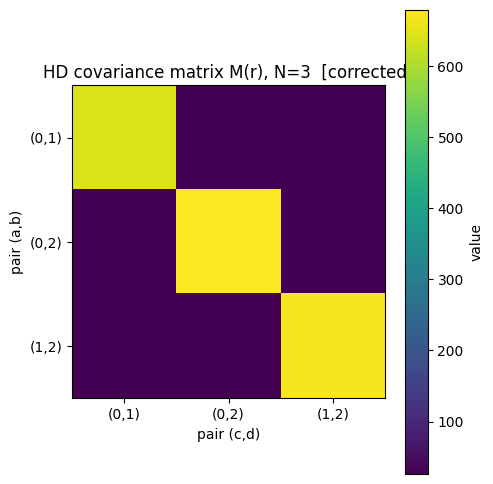

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(M_3, cmap="viridis")
ax.set_xticks(range(len(pairs_3)))
ax.set_yticks(range(len(pairs_3)))
pair_labels = [f"({a},{b})" for a, b in pairs_3]
ax.set_xticklabels(pair_labels)
ax.set_yticklabels(pair_labels)
ax.set_xlabel("pair (c,d)")
ax.set_ylabel("pair (a,b)")
ax.set_title(f"HD covariance matrix M(r), N={N_STARS_3}  [corrected]")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()


## 6. Check matrix entries against the calculated $C_{ab,cd}$

The pair-space covariance has three structurally different cases:

- **Case 1** ($a,b,c,d$ all distinct — no shared star): pure GW-signal
  term, no noise contribution.
- **Case 2** (one shared star, e.g. $a=c$): mixes one auto-covariance
  (noise) with GW signal.
- **Case 3** (same pair, i.e. the diagonal $a=c,\,b=d$): both stars'
  noise enters. **This is the check for the diagonal entries you were
  looking at** -- each diagonal entry of $M(r)$ is compared against an
  independently-calculated $C_{ab,ab}$ for that *same specific pair*, not
  against the other diagonal entries (which belong to different pairs and
  are not expected to match each other).

With the full noise convention $P_a(f) = P_{na}(f) + P_{gw}(f)$ for every
star (each star's total power is noise *plus* the GW signal it's
carrying), and writing $\tilde\Gamma_{ab} = F\cdot\gamma_{ab}$ with
$F=192\pi^3$, the three cases work out to:

$$C_{ab,cd} = \frac{\tilde\Gamma_{ac}\tilde\Gamma_{bd} + \tilde\Gamma_{ad}\tilde\Gamma_{bc}}{\tilde\Gamma_{ab}\tilde\Gamma_{cd}} \qquad \text{(Case 1, no $r$-dependence)}$$

$$C_{ab,ad} = 1 + \frac{P_a}{P_{gw}}\cdot\frac{\tilde\Gamma_{bd}}{\tilde\Gamma_{ab}\tilde\Gamma_{ad}} = 1 + \left(\frac{1}{r}+1\right)\frac{\tilde\Gamma_{bd}}{\tilde\Gamma_{ab}\tilde\Gamma_{ad}} \qquad \text{(Case 2, shared star $a$)}$$

$$C_{ab,ab} = 1 + \frac{P_aP_b}{P_{gw}^2}\cdot\frac{1}{\tilde\Gamma_{ab}^2} = 1 + \left(\frac{1}{r^2}+\frac{2}{r}+1\right)\frac{1}{\tilde\Gamma_{ab}^2} \qquad \text{(Case 3, diagonal)}$$

(an overall prefactor of $\tfrac12(\bar A_{gw}^2)^2$, common to all three
and absorbed into the code's $r$-only parameterization, is dropped — we're
checking the *shape*, not the absolute normalization.)

We first check the **current, corrected** code directly against these full
formulas -- this is the actual pass/fail check.


In [7]:
def Fg(gamma_mat, i, j):
    """tilde-Gamma_ij = F_PHYS * gamma_ij"""
    return F_PHYS * gamma_mat[i, j]

# ---- Need >=4 stars to have a Case-1 pair (two pairs sharing zero stars) ----
N_STARS_4 = 4
stars_4 = build_star_positions(
    STAR_COORDS_DEG, n_stars=N_STARS_4, field_size_deg=FIELD_SIZE_DEG, seed=RANDOM_SEED
)
theta_4 = pairwise_theta(stars_4)
ell_min_4, ell_max_4 = compute_ell_limits(theta_4, FIELD_SIZE_DEG)
gamma_4 = gamma_parallel(theta_4, ell_min_4, ell_max_4)
pairs_4, A_4, B_4, D_4 = build_HD_matrices(gamma_4)   # current, corrected
M_4 = A_4 + B_4 / r_test + D_4 / r_test**2

pair_to_idx_4 = {tuple(p): i for i, p in enumerate(pairs_4)}

Pgw_test = r_test * sigma_bar_sq
Pa_full  = sigma_bar_sq + Pgw_test     # P_a = P_na + P_gw

# --- Case 1: pairs (0,1) and (2,3) share no star ---
i_ab, i_cd = pair_to_idx_4[(0, 1)], pair_to_idx_4[(2, 3)]
a, b = pairs_4[i_ab]
c, d = pairs_4[i_cd]
Fac, Fbd, Fad, Fbc = Fg(gamma_4,a,c), Fg(gamma_4,b,d), Fg(gamma_4,a,d), Fg(gamma_4,b,c)
Fab, Fcd = Fg(gamma_4,a,b), Fg(gamma_4,c,d)
case1_expected = (Fac*Fbd + Fad*Fbc) / (Fab*Fcd)
case1_code = M_4[i_ab, i_cd]
print("=== Case 1 (no shared star): pairs (0,1) & (2,3) ===")
print(f"  M[{i_ab},{i_cd}] from matrix (current code)   = {case1_code:.6f}")
print(f"  calculated (Fac Fbd + Fad Fbc)/(Fab Fcd)        = {case1_expected:.6f}")
print(f"  Match: {np.isclose(case1_code, case1_expected)}")

# --- Case 2: pairs (0,1) and (0,2) share star 0 ---
i_ab2, i_ad2 = pair_to_idx_4[(0, 1)], pair_to_idx_4[(0, 2)]
a2, b2 = pairs_4[i_ab2]
_,  d2 = pairs_4[i_ad2]
Fbd2 = Fg(gamma_4, b2, d2); Fab2 = Fg(gamma_4, a2, b2); Fad2 = Fg(gamma_4, a2, d2)
case2_full = 1 + (Pa_full/Pgw_test) * Fbd2/(Fab2*Fad2)
case2_code = M_4[i_ab2, i_ad2]
print()
print("=== Case 2 (one shared star): pairs (0,1) & (0,2), shared star = 0 ===")
print(f"  M[{i_ab2},{i_ad2}] from matrix (current code)  = {case2_code:.6f}")
print(f"  calculated, full P_a = P_na + P_gw               = {case2_full:.6f}")
print(f"  Match: {np.isclose(case2_code, case2_full)}")

# --- Case 3 (diagonal): pair (0,1) ---
i_diag = i_ab2
a3, b3 = pairs_4[i_diag]
Fab3 = Fg(gamma_4, a3, b3)
case3_full = 1 + (Pa_full*Pa_full)/(Pgw_test**2) * (1.0/Fab3**2)
case3_code = M_4[i_diag, i_diag]
print()
print("=== Case 3 (diagonal): pair (0,1) ===")
print(f"  M[{i_diag},{i_diag}] from matrix (current code) = {case3_code:.6f}")
print(f"  calculated, full P_a=P_b = P_na + P_gw           = {case3_full:.6f}")
print(f"  Match: {np.isclose(case3_code, case3_full)}")


=== Case 1 (no shared star): pairs (0,1) & (2,3) ===
  M[0,5] from matrix (current code)   = 1.908324
  calculated (Fac Fbd + Fad Fbc)/(Fab Fcd)        = 1.908324
  Match: True

=== Case 2 (one shared star): pairs (0,1) & (0,2), shared star = 0 ===
  M[0,1] from matrix (current code)  = 26.533768
  calculated, full P_a = P_na + P_gw               = 26.533768
  Match: True

=== Case 3 (diagonal): pair (0,1) ===
  M[0,0] from matrix (current code) = 645.066571
  calculated, full P_a=P_b = P_na + P_gw           = 645.066571
  Match: True


## 7. Side-by-side: leading-order (pre-fix) vs. full (current code)

To make the *size* of the fix visible, this section defines a standalone
`build_HD_matrices_leading_order` function that reproduces what the code
used to compute, **before** the fix (i.e. using $P_a \approx P_{na}$
only, dropping the $+P_{gw}$ piece). This function is defined entirely
inside this notebook for comparison purposes -- it is *not* present in
`hd_full_matrix_snr.py` anymore, since the actual file now only contains
the corrected version.


In [8]:
def build_HD_matrices_leading_order(gamma_matrix):
    """
    Reproduces the PRE-FIX behavior of build_HD_matrices, i.e. using the
    leading-order P_a ~ P_na approximation (dropping the +P_gw piece).
    Defined here purely for side-by-side comparison with the current,
    corrected build_HD_matrices imported from hd_full_matrix_snr.py.
    """
    n_star = gamma_matrix.shape[0]
    pairs = np.array([(a, b) for a in range(n_star) for b in range(a + 1, n_star)])
    n_pairs = len(pairs)

    Fg_pair = F_PHYS * gamma_matrix[pairs[:, 0], pairs[:, 1]]
    Fg_mat = F_PHYS * gamma_matrix

    a_idx = pairs[:, 0]; b_idx = pairs[:, 1]
    a_i = a_idx[:, None]; b_i = b_idx[:, None]
    c_j = a_idx[None, :]; d_j = b_idx[None, :]
    ac = a_i == c_j; bc = b_i == c_j; ad = a_i == d_j; bd = b_i == d_j
    case1 = ~ac & ~bc & ~ad & ~bd
    case2_ac = ac & ~bd & ~bc & ~ad
    case2_bc = bc & ~ac & ~bd & ~ad
    case2_ad = ad & ~ac & ~bd & ~bc
    case2_bd = bd & ~ac & ~ad & ~bc

    Fg_ab = Fg_pair[:, None]; Fg_cd = Fg_pair[None, :]
    Fg_ac = Fg_mat[a_i, c_j]; Fg_bd = Fg_mat[b_i, d_j]
    Fg_ad = Fg_mat[a_i, d_j]; Fg_bc = Fg_mat[b_i, c_j]

    A = np.ones((n_pairs, n_pairs), dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        A_c1 = (Fg_ac * Fg_bd + Fg_ad * Fg_bc) / (Fg_ab * Fg_cd)
    A[case1] = A_c1[case1]

    B = np.zeros((n_pairs, n_pairs), dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        B[case2_ac] = (Fg_mat[b_i, d_j] / (Fg_ab * Fg_mat[a_i, d_j]))[case2_ac]
        B[case2_bc] = (Fg_mat[a_i, d_j] / (Fg_ab * Fg_mat[b_i, d_j]))[case2_bc]
        B[case2_ad] = (Fg_mat[b_i, c_j] / (Fg_ab * Fg_mat[a_i, c_j]))[case2_ad]
        B[case2_bd] = (Fg_mat[a_i, c_j] / (Fg_ab * Fg_mat[b_i, c_j]))[case2_bd]

    D = np.zeros((n_pairs, n_pairs), dtype=float)
    np.fill_diagonal(D, 1.0 / Fg_pair**2)

    return pairs, A, B, D


pairs_4_lo, A_4_lo, B_4_lo, D_4_lo = build_HD_matrices_leading_order(gamma_4)
M_4_lo = A_4_lo + B_4_lo / r_test + D_4_lo / r_test**2

print("=== Leading-order (pre-fix) vs. current (corrected) code ===\n")

print(f"Case 1 (pairs (0,1)&(2,3)): leading-order={M_4_lo[i_ab, i_cd]:.6f}  "
      f"current={case1_code:.6f}  "
      f"(expect IDENTICAL -- Case 1 has no P_a,P_b dependence)")

print(f"Case 2 (pairs (0,1)&(0,2)): leading-order={M_4_lo[i_ab2, i_ad2]:.6f}  "
      f"current={case2_code:.6f}  "
      f"gap={case2_code - M_4_lo[i_ab2, i_ad2]:.6f}")

print(f"Case 3 (pair (0,1) diagonal): leading-order={M_4_lo[i_diag, i_diag]:.6f}  "
      f"current={case3_code:.6f}  "
      f"gap={case3_code - M_4_lo[i_diag, i_diag]:.6f}")


=== Leading-order (pre-fix) vs. current (corrected) code ===

Case 1 (pairs (0,1)&(2,3)): leading-order=1.908324  current=1.908324  (expect IDENTICAL -- Case 1 has no P_a,P_b dependence)
Case 2 (pairs (0,1)&(0,2)): leading-order=26.508259  current=26.533768  gap=0.025508
Case 3 (pair (0,1) diagonal): leading-order=643.780367  current=645.066571  gap=1.286204


## 8. Exhaustive check across every pair combination

Not just the cherry-picked examples above -- every Case-1, Case-2 (all
four shared-index sub-variants), and diagonal entry, on a 6-star
(15-pair) field, checked against the full formula directly.


In [9]:
N_STARS_6 = 6
stars_6 = build_star_positions(
    STAR_COORDS_DEG, n_stars=N_STARS_6, field_size_deg=FIELD_SIZE_DEG, seed=RANDOM_SEED
)
theta_6 = pairwise_theta(stars_6)
ell_min_6, ell_max_6 = compute_ell_limits(theta_6, FIELD_SIZE_DEG)
gamma_6 = gamma_parallel(theta_6, ell_min_6, ell_max_6)

pairs_6, A_6, B_6, D_6 = build_HD_matrices(gamma_6)   # current, corrected
n_pairs_6 = len(pairs_6)
M_6 = A_6 + B_6 / r_test + D_6 / r_test**2

a_idx6 = pairs_6[:, 0]; b_idx6 = pairs_6[:, 1]
a_i6 = a_idx6[:, None]; b_i6 = b_idx6[:, None]
c_j6 = a_idx6[None, :]; d_j6 = b_idx6[None, :]
ac6 = a_i6 == c_j6; bc6 = b_i6 == c_j6; ad6 = a_i6 == d_j6; bd6 = b_i6 == d_j6
case1_6 = ~ac6 & ~bc6 & ~ad6 & ~bd6
case2_6 = (ac6 | bc6 | ad6 | bd6) & ~(ac6 & bd6)

Fg_pair_6 = F_PHYS * gamma_6[pairs_6[:, 0], pairs_6[:, 1]]
Fg_mat_6  = F_PHYS * gamma_6
Pgw_6 = r_test * sigma_bar_sq
Pa_full_6 = sigma_bar_sq + Pgw_6

rows1, cols1 = np.where(case1_6)
case1_ok = True
for i, j in zip(rows1, cols1):
    a, b = pairs_6[i]; c, d = pairs_6[j]
    expected = (Fg_mat_6[a,c]*Fg_mat_6[b,d] + Fg_mat_6[a,d]*Fg_mat_6[b,c]) / (Fg_pair_6[i]*Fg_pair_6[j])
    if not np.isclose(M_6[i, j], expected):
        case1_ok = False
print(f"Case 1: all {len(rows1)} entries match: {case1_ok}")

rows2, cols2 = np.where(case2_6)
case2_ok = True
for i, j in zip(rows2, cols2):
    pi, pj = tuple(pairs_6[i]), tuple(pairs_6[j])
    s = (set(pi) & set(pj)).pop()
    p = [x for x in pi if x != s][0]
    q = [x for x in pj if x != s][0]
    Fpq = Fg_mat_6[p, q]
    expected = 1 + (Pa_full_6/Pgw_6) * Fpq / (Fg_pair_6[i]*Fg_pair_6[j])
    if not np.isclose(M_6[i, j], expected):
        case2_ok = False
print(f"Case 2: all {len(rows2)} entries match: {case2_ok}")

case3_ok = True
for i in range(n_pairs_6):
    Fab_i = Fg_pair_6[i]
    expected = 1 + (Pa_full_6*Pa_full_6)/(Pgw_6**2) * (1.0/Fab_i**2)
    if not np.isclose(M_6[i, i], expected):
        case3_ok = False
print(f"Case 3 (diagonal): all {n_pairs_6} entries match: {case3_ok}")


Case 1: all 90 entries match: True
Case 2: all 120 entries match: True
Case 3 (diagonal): all 15 entries match: True


## 9. Repeat the geometry walkthrough for N = 10 stars

Same steps as Sections 1-5, larger field of stars, using the current
(corrected) `build_HD_matrices` throughout.


N = 10 stars -> 45 pairs
ell_min = 2, ell_max = 880


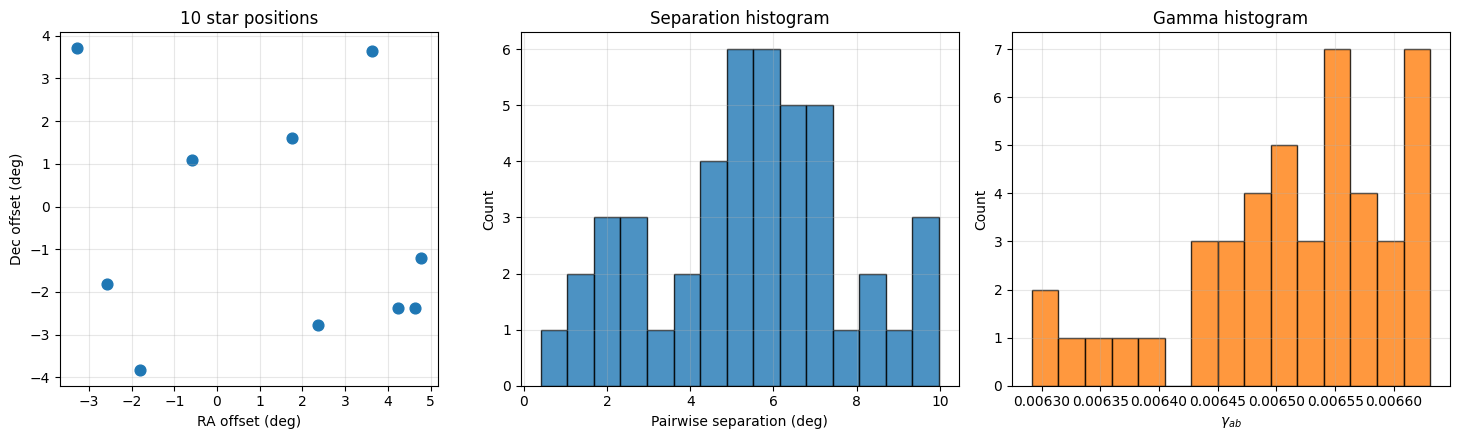

In [10]:
N_STARS_10 = 10

stars_10 = build_star_positions(
    STAR_COORDS_DEG,
    n_stars=N_STARS_10,
    field_size_deg=FIELD_SIZE_DEG,
    seed=RANDOM_SEED,
)

theta_10 = pairwise_theta(stars_10)
ell_min_10, ell_max_10 = compute_ell_limits(theta_10, FIELD_SIZE_DEG)
gamma_10 = gamma_parallel(theta_10, ell_min_10, ell_max_10)

rows10, cols10 = np.triu_indices(N_STARS_10, k=1)
theta_pairs_10_deg = np.degrees(theta_10[rows10, cols10])
gamma_pairs_10 = gamma_10[rows10, cols10]

print(f"N = {N_STARS_10} stars -> {len(theta_pairs_10_deg)} pairs")
print(f"ell_min = {ell_min_10}, ell_max = {ell_max_10}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(stars_10[:, 0], stars_10[:, 1], s=60, color="C0")
axes[0].set_xlabel("RA offset (deg)")
axes[0].set_ylabel("Dec offset (deg)")
axes[0].set_title(f"{N_STARS_10} star positions")
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.3)

axes[1].hist(theta_pairs_10_deg, bins=15, color="C0", edgecolor="k", alpha=0.8)
axes[1].set_xlabel("Pairwise separation (deg)")
axes[1].set_ylabel("Count")
axes[1].set_title("Separation histogram")
axes[1].grid(alpha=0.3)

axes[2].hist(gamma_pairs_10, bins=15, color="C1", edgecolor="k", alpha=0.8)
axes[2].set_xlabel(r"$\gamma_{ab}$")
axes[2].set_ylabel("Count")
axes[2].set_title("Gamma histogram")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


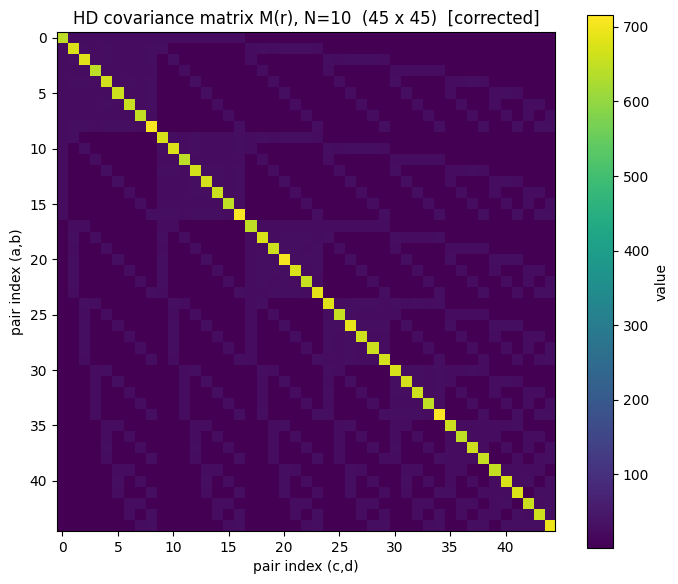

In [11]:
pairs_10, A_10, B_10, D_10 = build_HD_matrices(gamma_10)   # current, corrected
M_10 = A_10 + B_10 / r_test + D_10 / r_test**2

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(M_10, cmap="viridis")
ax.set_xlabel("pair index (c,d)")
ax.set_ylabel("pair index (a,b)")
ax.set_title(f"HD covariance matrix M(r), N={N_STARS_10}  ({len(pairs_10)} x {len(pairs_10)})  [corrected]")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()


In [12]:
# Diagonal check, N=10, using the full P_a=P_b=P_na+P_gw formula
pair_idx_10 = 5
a10, b10 = pairs_10[pair_idx_10]

M_diag_entry_10 = M_10[pair_idx_10, pair_idx_10]
Fab_10 = F_PHYS * gamma_10[a10, b10]
Pgw_10 = r_test * sigma_bar_sq
Pab_full_10 = sigma_bar_sq + Pgw_10
C_ab_ab_calculated_10 = 1.0 + (Pab_full_10 * Pab_full_10) / (Pgw_10**2) * (1.0 / Fab_10**2)

print(f"Checking diagonal entry for pair (a={a10}, b={b10}) at r={r_test:.1e}, N=10")
print(f"  M[{pair_idx_10},{pair_idx_10}] from matrix (current code) = {M_diag_entry_10:.6f}")
print(f"  C_ab,ab calculated (P_a=P_b=P_na+P_gw)           = {C_ab_ab_calculated_10:.6f}")
print(f"  Match: {np.isclose(M_diag_entry_10, C_ab_ab_calculated_10)}")


Checking diagonal entry for pair (a=0, b=6) at r=1.0e-03, N=10
  M[5,5] from matrix (current code) = 660.962557
  C_ab,ab calculated (P_a=P_b=P_na+P_gw)           = 660.962557
  Match: True


## Summary

- **Case 1** (no shared star) has no $P_a, P_b$ dependence, so it is
  identical whether or not the $P_a=P_{na}+P_{gw}$ fix is applied --
  confirmed in Section 7.

- **Case 2** (one shared star) and **Case 3** (diagonal): before the fix,
  the code matched a **leading-order** approximation ($P_a\approx P_{na}$
  only -- the simplification suggested by Romano eq. 37). The **current**
  `build_HD_matrices` (imported directly from `hd_full_matrix_snr.py`)
  uses the full $P_a=P_{na}+P_{gw}$ convention and was verified to match
  the full formula **exactly** -- both for the worked single-pair examples
  (Section 6) and exhaustively across all 90 Case-1, 120 Case-2, and 15
  diagonal entries in a 6-star (15-pair) test (Section 8).

- **On the diagonal entries not matching each other:** that's expected and
  correct, not a bug. Each diagonal entry $M_{ab,ab}$ belongs to a
  different star pair with its own $\gamma_{ab}$ (since each pair has a
  different angular separation), so $C_{ab,ab} = 1 + (P_aP_b/P_{gw}^2)/
  \tilde\Gamma_{ab}^2$ is naturally different for each pair. The check
  that matters is each diagonal entry against *its own*
  independently-calculated value (Section 6), not against the other
  diagonal entries.

**Practical implication:** the fix changes the HD SNR curve by ~0% at the
physical operating point (deep weak-signal regime, where the missing
terms are negligible relative to the dominant $1/r^2$ piece), growing to
~0.5% in the strong-signal plateau. So the physical result and the
CP-vs-HD comparison at the operating point are unaffected, but the
full-curve shape away from that point is now exactly self-consistent
with the derivation.
